In [1]:
%run ../scripts/notebook_settings.py
import sgkit as sg
import xarray as xr
import glob

In [2]:
table_desc = "~/primatediversity/data/gVCFs_recalling_10_12_2024_metadata/plots/SupTable_Sample_Stats_wGT_QC_MQ.tsv"
metadata_path = "~/primatediversity/data/gVCFs_recalling_10_12_2024_metadata/"

metadata_table = pd.read_csv(table_desc, sep="\t")

metadata_20x_filt = metadata_table.loc[(metadata_table.finalQC != "fail")
                              & (metadata_table.cov_chrA >= 20)
                              & (metadata_table.remove_as_relative != True)
                              & (metadata_table.remove_manual != True)
                              & (~metadata_table.ID.str.startswith("SAMEA11633"))
                             ]

In [3]:
count_sub = metadata_20x_filt.loc[~metadata_20x_filt.cov_chrX.isna()][["gSEX", "group", "species_genotyping", "species"]].value_counts().reset_index()
used_species = count_sub.loc[(count_sub.gSEX == "F") | ((count_sub.gSEX == "M") & (count_sub["count"] >= 2))].species_genotyping.unique()

Loading in all the species.

In [4]:
df_l = []
for long_form in used_species:
    df_path = "../results/lifted_window_stats_20x_inds/{}_10kb_pi_windowed_annotated.txt".format(long_form)
    s_df = pd.read_csv(df_path, sep="\t")
    s_df["species"] = long_form
    df_l.append(s_df)
all_pi_df = pd.concat(df_l)

In [5]:
chr_names = ['NC_060925.1', 'NC_060926.1', 'NC_060927.1', 'NC_060928.1',
       'NC_060929.1', 'NC_060930.1', 'NC_060931.1', 'NC_060932.1',
       'NC_060933.1', 'NC_060934.1', 'NC_060935.1', 'NC_060936.1',
       'NC_060937.1', 'NC_060938.1', 'NC_060939.1', 'NC_060940.1',
       'NC_060941.1', 'NC_060942.1', 'NC_060943.1', 'NC_060944.1',
       'NC_060945.1', 'NC_060946.1', 'NC_060947.1']
chr_tag = ["chrX" if i == 22 else "aut" for i in range(len(chr_names))]
all_pi_df["chr_type"] = all_pi_df.chrom.map(dict(zip(chr_names, chr_tag)))
all_pi_df

,chrom,window_100kb,pi_window,mapped_bases,pi_per_mapped_base,genes,max_genes,largest_gene,largest_gene_cov,species,chr_type
0,NC_060925.1,0,220.560738,47016,0.004691,NaN,0,NaN,0.00000,Macaca_fascicularis_ssp,aut
1,NC_060925.1,100000,4.757545,1214,0.003919,['OR4F21'],0,OR4F21,0.00938,Macaca_fascicularis_ssp,aut
2,NC_060925.1,200000,212.822104,58860,0.003616,NaN,0,NaN,0.00000,Macaca_fascicularis_ssp,aut
3,NC_060925.1,300000,269.197770,63277,0.004254,['SAMD11' 'NOC2L' 'PLEKHN1' 'KLHL17'],0,SAMD11,0.17321,Macaca_fascicularis_ssp,aut
4,NC_060925.1,400000,237.559592,81586,0.002912,['AGRN' 'PERM1' 'PLEKHN1' 'HES4' 'ISG15'],0,AGRN,0.34747,Macaca_fascicularis_ssp,aut
...,...,...,...,...,...,...,...,...,...,...,...
28336,NC_060947.1,153800000,0.678400,60158,0.000011,['TMLHE'],0,TMLHE,0.94993,Semnopithecus_schistaceus_ssp,chrX
28337,NC_060947.1,153900000,0.258067,67648,0.000004,['SPRY3'],0,SPRY3,0.00867,Semnopithecus_schistaceus_ssp,chrX
28338,NC_060947.1,154000000,0.819000,48192,0.000017,NaN,0,NaN,0.00000,Semnopithecus_schistaceus_ssp,chrX
28339,NC_060947.1,154100000,1.534267,64030,0.000024,['VAMP7'],0,VAMP7,0.52682,Semnopithecus_schistaceus_ssp,chrX


In [6]:
lifted_species = all_pi_df.loc[(all_pi_df.chrom == 'NC_060947.1')].species.unique()
len(lifted_species)

193

In [7]:
# Worst and best performing species on chrX
all_pi_df.loc[(all_pi_df.chrom == "NC_060947.1") & (~all_pi_df.pi_window.isna())
             & (all_pi_df.mapped_bases >= 25000)]["species"].value_counts()

species
Pongo_abelii_ssp              1483
Pongo_pygmaeus_ssp            1481
Pan_troglodytes_ssp           1477
Pan_paniscus_ssp              1476
Gorilla_beringei_ssp          1473
                              ... 
Lemur_catta_ssp                604
Hapalemur_griseus_ssp          590
Hapalemur_meridionalis_ssp     589
Prolemur_simus_ssp             589
Eulemur_mongoz_ssp               2
Name: count, Length: 193, dtype: int64

In [14]:
# Removing the eulemur
all_pi_df = all_pi_df.loc[all_pi_df.species != "Eulemur_mongoz_ssp"].copy()

<Axes: xlabel='mapped_bases', ylabel='Proportion'>

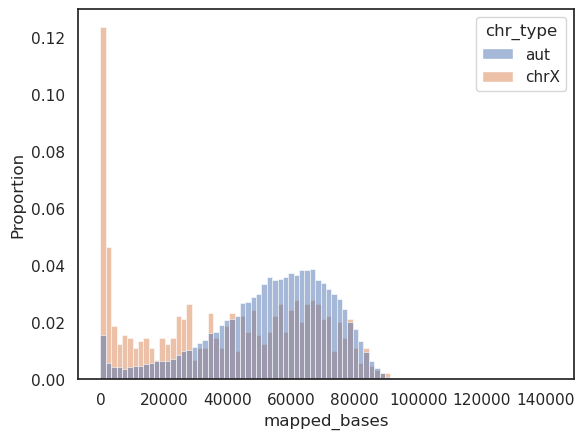

In [15]:
sns.histplot(all_pi_df.loc[all_pi_df.species == "Prolemur_simus_ssp"],
             x="mapped_bases", hue="chr_type", common_norm=False, stat="proportion")

<Axes: xlabel='mapped_bases', ylabel='Proportion'>

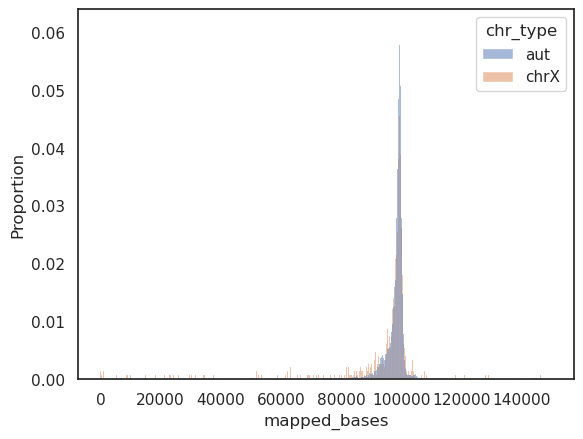

In [16]:
sns.histplot(all_pi_df.loc[(all_pi_df.species == "Gorilla_beringei_ssp") & (all_pi_df.mapped_bases <= 150000)],
             x="mapped_bases", hue="chr_type", common_norm=False, stat="proportion")

In [20]:
all_pi_df

,chrom,window_100kb,pi_window,mapped_bases,pi_per_mapped_base,genes,max_genes,largest_gene,largest_gene_cov,species,chr_type
0,NC_060925.1,0,220.560738,47016,0.004691,NaN,0,NaN,0.00000,Macaca_fascicularis_ssp,aut
1,NC_060925.1,100000,4.757545,1214,0.003919,['OR4F21'],0,OR4F21,0.00938,Macaca_fascicularis_ssp,aut
2,NC_060925.1,200000,212.822104,58860,0.003616,NaN,0,NaN,0.00000,Macaca_fascicularis_ssp,aut
3,NC_060925.1,300000,269.197770,63277,0.004254,['SAMD11' 'NOC2L' 'PLEKHN1' 'KLHL17'],0,SAMD11,0.17321,Macaca_fascicularis_ssp,aut
4,NC_060925.1,400000,237.559592,81586,0.002912,['AGRN' 'PERM1' 'PLEKHN1' 'HES4' 'ISG15'],0,AGRN,0.34747,Macaca_fascicularis_ssp,aut
...,...,...,...,...,...,...,...,...,...,...,...
28336,NC_060947.1,153800000,0.678400,60158,0.000011,['TMLHE'],0,TMLHE,0.94993,Semnopithecus_schistaceus_ssp,chrX
28337,NC_060947.1,153900000,0.258067,67648,0.000004,['SPRY3'],0,SPRY3,0.00867,Semnopithecus_schistaceus_ssp,chrX
28338,NC_060947.1,154000000,0.819000,48192,0.000017,NaN,0,NaN,0.00000,Semnopithecus_schistaceus_ssp,chrX
28339,NC_060947.1,154100000,1.534267,64030,0.000024,['VAMP7'],0,VAMP7,0.52682,Semnopithecus_schistaceus_ssp,chrX


In [24]:
count_callable_aut

,mapped_bases
species,
Allenopithecus_nigroviridis_ssp,25596
Allochrocebus_lhoesti_ssp,26088
Allochrocebus_preussi_ssp,26055
Alouatta_belzebul_ssp,24539
Alouatta_discolor_ssp,24527
...,...
Trachypithecus_pileatus_ssp,25450
Trachypithecus_poliocephalus_ssp,25735
Trachypithecus_vetulus_ssp,25697


In [30]:
all_pi_df

,chrom,window_100kb,pi_window,mapped_bases,pi_per_mapped_base,genes,max_genes,largest_gene,largest_gene_cov,species,chr_type,Group
0,NC_060925.1,0,220.560738,47016,0.004691,NaN,0,NaN,0.00000,Macaca_fascicularis_ssp,aut,OWM
1,NC_060925.1,100000,4.757545,1214,0.003919,['OR4F21'],0,OR4F21,0.00938,Macaca_fascicularis_ssp,aut,OWM
2,NC_060925.1,200000,212.822104,58860,0.003616,NaN,0,NaN,0.00000,Macaca_fascicularis_ssp,aut,OWM
3,NC_060925.1,300000,269.197770,63277,0.004254,['SAMD11' 'NOC2L' 'PLEKHN1' 'KLHL17'],0,SAMD11,0.17321,Macaca_fascicularis_ssp,aut,OWM
4,NC_060925.1,400000,237.559592,81586,0.002912,['AGRN' 'PERM1' 'PLEKHN1' 'HES4' 'ISG15'],0,AGRN,0.34747,Macaca_fascicularis_ssp,aut,OWM
...,...,...,...,...,...,...,...,...,...,...,...,...
28336,NC_060947.1,153800000,0.678400,60158,0.000011,['TMLHE'],0,TMLHE,0.94993,Semnopithecus_schistaceus_ssp,chrX,OWM
28337,NC_060947.1,153900000,0.258067,67648,0.000004,['SPRY3'],0,SPRY3,0.00867,Semnopithecus_schistaceus_ssp,chrX,OWM
28338,NC_060947.1,154000000,0.819000,48192,0.000017,NaN,0,NaN,0.00000,Semnopithecus_schistaceus_ssp,chrX,OWM
28339,NC_060947.1,154100000,1.534267,64030,0.000024,['VAMP7'],0,VAMP7,0.52682,Semnopithecus_schistaceus_ssp,chrX,OWM


[Text(0.5, 1.0, 'Relationship between mapped windows on autosomes and ChrX'),
 Text(0.5, 0, 'Autosomal windows above 50 % mapped bases'),
 Text(0, 0.5, 'ChrX windows above 50 % mapped bases')]

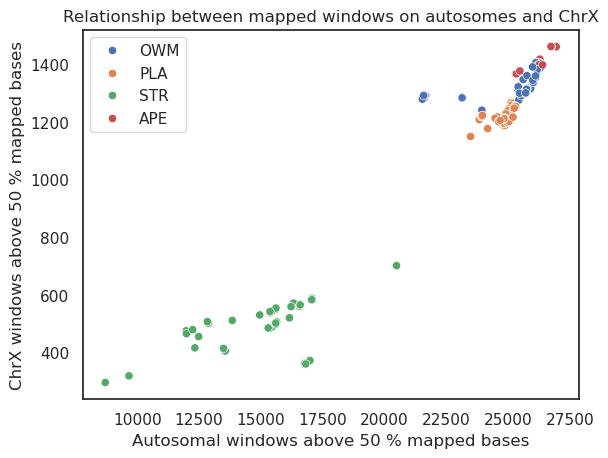

In [42]:
all_pi_df["Group"] = all_pi_df.species.map(dict(zip(metadata_20x_filt.species_genotyping, metadata_20x_filt.group)))
aut_pi = all_pi_df.loc[(all_pi_df.chr_type == "aut") & (~all_pi_df.pi_per_mapped_base.isna())]
chrX_pi = all_pi_df.loc[(all_pi_df.chr_type == "chrX") & (~all_pi_df.pi_per_mapped_base.isna())]
count_callable_chrX = chrX_pi.loc[chrX_pi.mapped_bases >= 50000].groupby(["species"])[["mapped_bases"]].count()
count_callable_aut = aut_pi.loc[aut_pi.mapped_bases >= 50000].groupby(["species"])[["mapped_bases"]].count()
group_list = count_callable_chrX.reset_index().species.map(dict(zip(metadata_20x_filt.species_genotyping, metadata_20x_filt.group)))
g = sns.scatterplot(x=count_callable_aut.mapped_bases, y=count_callable_chrX.mapped_bases, hue=list(group_list))
g.set(title="Relationship between mapped windows on autosomes and ChrX",
     xlabel="Autosomal windows above 50 % mapped bases", ylabel="ChrX windows above 50 % mapped bases")

Comparing reference and lifted versions.

In [44]:
df_l = []
for s in metadata_20x_filt.species_genotyping.unique():
    f_c = len(metadata_20x_filt.loc[metadata_20x_filt.gSEX == "F"])
    if f_c == 0:
        continue
    # Read het df
    pi_df_path = "../results/window_stats_20x_inds/{}_100kb_pi.txt".format(s)
    if os.path.exists("../results/window_stats_20x_inds/{}_100kb_pi.txt".format(s)):
        pi_df = pd.read_csv(pi_df_path, sep="\t")
    else:
        print("Not present:", s)
        continue
    df_l.append(pi_df)
all_pi_df_ref = pd.concat(df_l)

In [45]:
filt_pi_df = all_pi_df_ref.loc[all_pi_df_ref.callable_frac >= 0.5]
filt_pi_df["pi_adj"] = filt_pi_df.pi/filt_pi_df.callable_frac
mean_pi_df = filt_pi_df.loc[filt_pi_df.callable_frac >= 0.5].groupby(["species","chr_type"])[["pi", "pi_adj"]].mean()
mean_pi_df = mean_pi_df.reset_index().pivot(columns="chr_type", index="species", values="pi")
all_pi_df_aut = filt_pi_df.loc[filt_pi_df.chr_type == "aut"]
chrx_pi_df_aut = filt_pi_df.loc[filt_pi_df.chr_type == "chrX"]
mean_pi_df = mean_pi_df.reset_index()
mean_pi_df["CV_aut"] = (all_pi_df_aut.groupby(["species"])[["pi_adj"]].std() / all_pi_df_aut.groupby(["species"])[["pi_adj"]].mean()).reset_index()["pi_adj"]
CV_x_df = (chrx_pi_df_aut.groupby(["species"])[["pi_adj"]].std() / chrx_pi_df_aut.groupby(["species"])[["pi_adj"]].mean()).reset_index()
mean_pi_df["CV_x"] = mean_pi_df.species.map(dict(zip(CV_x_df.species, CV_x_df.pi_adj)))
mean_pi_df["Autosomal Pi per base"] = mean_pi_df.aut/100000
mean_pi_df["ChrX Pi per base"] = mean_pi_df.chrX/100000
mean_pi_df["X_a_ratio"] = mean_pi_df.chrX/mean_pi_df.aut
mean_pi_df["X/A ratio"] = mean_pi_df.chrX/mean_pi_df.aut

/tmp/46098634/ipykernel_37747/1028071112.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filt_pi_df["pi_adj"] = filt_pi_df.pi/filt_pi_df.callable_frac


In [46]:
mean_pi_df

chr_type,species,aut,chrX,CV_aut,CV_x,Autosomal Pi per base,ChrX Pi per base,X_a_ratio,X/A ratio
0,Allenopithecus_nigroviridis_ssp,138.049579,76.072058,0.443021,0.844265,0.001380,0.000761,0.551049,0.551049
1,Allochrocebus_lhoesti_ssp,271.244663,98.289917,0.504078,1.012021,0.002712,0.000983,0.362366,0.362366
2,Allochrocebus_preussi_ssp,264.850665,105.876125,0.687072,0.992060,0.002649,0.001059,0.399758,0.399758
3,Allochrocebus_solatus_ssp,302.877750,NaN,0.695848,NaN,0.003029,NaN,NaN,NaN
4,Alouatta_belzebul_ssp,510.169378,366.218989,0.262548,0.257281,0.005102,0.003662,0.717838,0.717838
...,...,...,...,...,...,...,...,...,...
245,Trachypithecus_poliocephalus_ssp,65.467857,38.032207,0.838183,0.759609,0.000655,0.000380,0.580929,0.580929
246,Trachypithecus_vetulus_ssp,232.827177,134.729050,0.462224,0.514592,0.002328,0.001347,0.578665,0.578665
247,Varecia_rubra_ssp,151.034928,NaN,0.768758,NaN,0.001510,NaN,NaN,NaN
248,Varecia_variegata_ssp,211.144432,120.002801,0.424734,0.613653,0.002111,0.001200,0.568345,0.568345


In [47]:
all_pi_df

,chrom,window_100kb,pi_window,mapped_bases,pi_per_mapped_base,genes,max_genes,largest_gene,largest_gene_cov,species,chr_type,Group
0,NC_060925.1,0,220.560738,47016,0.004691,NaN,0,NaN,0.00000,Macaca_fascicularis_ssp,aut,OWM
1,NC_060925.1,100000,4.757545,1214,0.003919,['OR4F21'],0,OR4F21,0.00938,Macaca_fascicularis_ssp,aut,OWM
2,NC_060925.1,200000,212.822104,58860,0.003616,NaN,0,NaN,0.00000,Macaca_fascicularis_ssp,aut,OWM
3,NC_060925.1,300000,269.197770,63277,0.004254,['SAMD11' 'NOC2L' 'PLEKHN1' 'KLHL17'],0,SAMD11,0.17321,Macaca_fascicularis_ssp,aut,OWM
4,NC_060925.1,400000,237.559592,81586,0.002912,['AGRN' 'PERM1' 'PLEKHN1' 'HES4' 'ISG15'],0,AGRN,0.34747,Macaca_fascicularis_ssp,aut,OWM
...,...,...,...,...,...,...,...,...,...,...,...,...
28336,NC_060947.1,153800000,0.678400,60158,0.000011,['TMLHE'],0,TMLHE,0.94993,Semnopithecus_schistaceus_ssp,chrX,OWM
28337,NC_060947.1,153900000,0.258067,67648,0.000004,['SPRY3'],0,SPRY3,0.00867,Semnopithecus_schistaceus_ssp,chrX,OWM
28338,NC_060947.1,154000000,0.819000,48192,0.000017,NaN,0,NaN,0.00000,Semnopithecus_schistaceus_ssp,chrX,OWM
28339,NC_060947.1,154100000,1.534267,64030,0.000024,['VAMP7'],0,VAMP7,0.52682,Semnopithecus_schistaceus_ssp,chrX,OWM


In [48]:
mean_pi_df_human = all_pi_df.loc[all_pi_df.mapped_bases >= 50000].groupby(["species","chr_type"])[["pi_per_mapped_base"]].mean()
mean_pi_df_human = mean_pi_df_human.reset_index().pivot(columns="chr_type", index="species", values="pi_per_mapped_base")
all_pi_df_aut_human = all_pi_df.loc[all_pi_df.chr_type == "aut"]
chrx_pi_df_aut_human = all_pi_df.loc[all_pi_df.chr_type == "chrX"]
mean_pi_df_human = mean_pi_df_human.reset_index()
mean_pi_df_human["Autosomal Pi per base"] = mean_pi_df_human.aut
mean_pi_df_human["ChrX Pi per base"] = mean_pi_df_human.chrX
mean_pi_df_human["X_a_ratio"] = mean_pi_df_human.chrX/mean_pi_df_human.aut
mean_pi_df_human["X/A ratio"] = mean_pi_df_human.chrX/mean_pi_df_human.aut

In [58]:
mean_pi_df["human_X/A"] = mean_pi_df.species.map(dict(zip(mean_pi_df_human["species"],
                                                          mean_pi_df_human["X_a_ratio"])))
mean_pi_df["human_A"] = mean_pi_df.species.map(dict(zip(mean_pi_df_human["species"],
                                                          mean_pi_df_human["Autosomal Pi per base"])))
mean_pi_df["human_X"] = mean_pi_df.species.map(dict(zip(mean_pi_df_human["species"],
                                                          mean_pi_df_human["ChrX Pi per base"])))

In [57]:
mean_pi_df

chr_type,species,aut,chrX,CV_aut,CV_x,Autosomal Pi per base,ChrX Pi per base,X_a_ratio,X/A ratio,human_X/A,human_A
0,Allenopithecus_nigroviridis_ssp,138.049579,76.072058,0.443021,0.844265,0.001380,0.000761,0.551049,0.551049,0.554035,0.001369
1,Allochrocebus_lhoesti_ssp,271.244663,98.289917,0.504078,1.012021,0.002712,0.000983,0.362366,0.362366,0.355744,0.002723
2,Allochrocebus_preussi_ssp,264.850665,105.876125,0.687072,0.992060,0.002649,0.001059,0.399758,0.399758,0.392304,0.002660
3,Allochrocebus_solatus_ssp,302.877750,NaN,0.695848,NaN,0.003029,NaN,NaN,NaN,NaN,NaN
4,Alouatta_belzebul_ssp,510.169378,366.218989,0.262548,0.257281,0.005102,0.003662,0.717838,0.717838,0.725502,0.005184
...,...,...,...,...,...,...,...,...,...,...,...
245,Trachypithecus_poliocephalus_ssp,65.467857,38.032207,0.838183,0.759609,0.000655,0.000380,0.580929,0.580929,0.590584,0.000654
246,Trachypithecus_vetulus_ssp,232.827177,134.729050,0.462224,0.514592,0.002328,0.001347,0.578665,0.578665,0.608212,0.002366
247,Varecia_rubra_ssp,151.034928,NaN,0.768758,NaN,0.001510,NaN,NaN,NaN,NaN,NaN
248,Varecia_variegata_ssp,211.144432,120.002801,0.424734,0.613653,0.002111,0.001200,0.568345,0.568345,0.554142,0.002077


[Text(0.5, 1.0, 'Autosomal π per base in reference and lift'),
 Text(0.5, 0, 'Autosomal π in reference'),
 Text(0, 0.5, 'Autosomal π in lifted coordinates')]

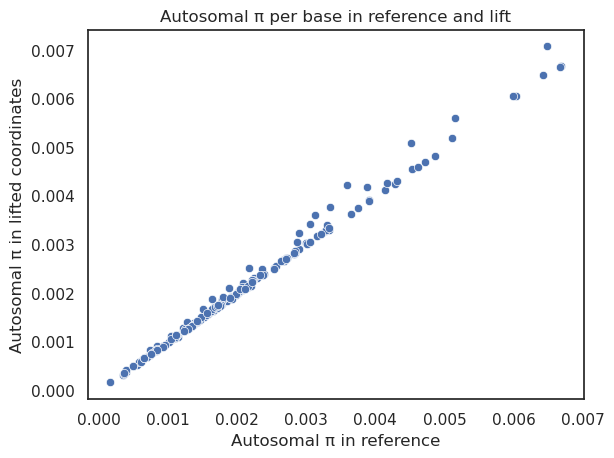

In [56]:
g = sns.scatterplot(mean_pi_df, x="Autosomal Pi per base", y="human_A")
g.set(title="Autosomal Pi per base in reference and lift", xlabel="Autosomal Pi in reference",
      ylabel="Autosomal Pi in lifted coordinates")

[Text(0.5, 1.0, 'ChrX Pi per base in reference and lift'),
 Text(0.5, 0, 'ChrX Pi in reference'),
 Text(0, 0.5, 'ChrX Pi in lifted coordinates')]

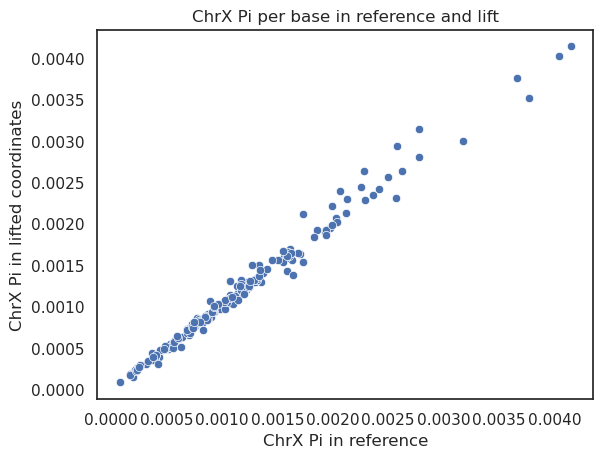

In [59]:
g = sns.scatterplot(mean_pi_df, x="ChrX Pi per base", y="human_X")
g.set(title="ChrX Pi per base in reference and lift", xlabel="ChrX Pi in reference",
      ylabel="ChrX Pi in lifted coordinates")

[Text(0.5, 0, 'Ratio of autosomal Pi between lift and reference')]

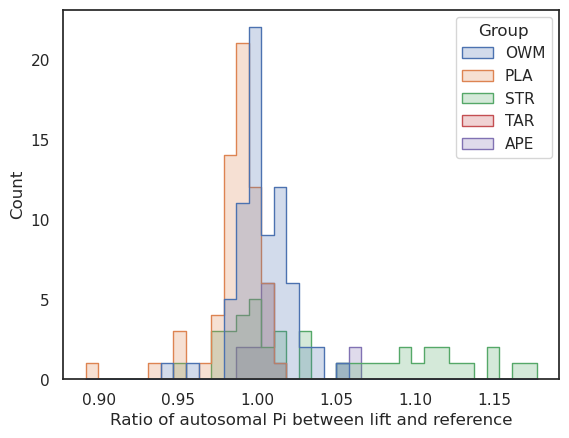

In [74]:
mean_pi_df["Group"] = mean_pi_df.reset_index().species.map(dict(zip(metadata_20x_filt.species_genotyping, metadata_20x_filt.group)))
mean_pi_df["A_lift/A_ref"] = mean_pi_df["human_A"]/mean_pi_df["Autosomal Pi per base"]
g = sns.histplot(mean_pi_df, x="A_lift/A_ref", hue="Group", element="step")
g.set(xlabel = "Ratio of autosomal Pi between lift and reference")

[Text(0.5, 0, 'Ratio of chrX Pi between lift and reference')]

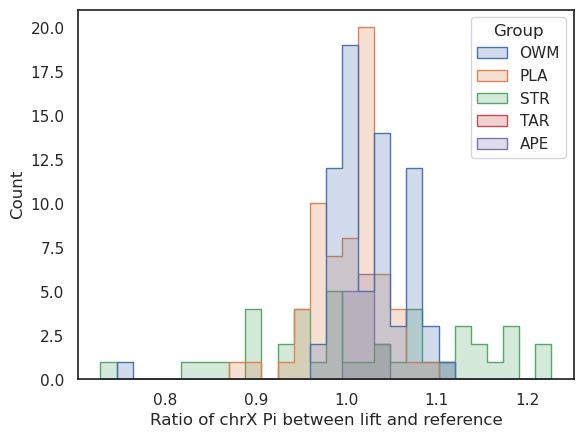

In [75]:
mean_pi_df["X_lift/X_ref"] = mean_pi_df["human_X"]/mean_pi_df["ChrX Pi per base"]
g = sns.histplot(mean_pi_df, x="X_lift/X_ref", hue="Group", element="step")
g.set(xlabel = "Ratio of chrX Pi between lift and reference")

In [23]:
mean_pi_df[["Autosomal Pi per base", "human_A"]].corr()

chr_type,Autosomal Pi per base,human_A
chr_type,,
Autosomal Pi per base,1.000000,0.996923
human_A,0.996923,1.000000


In [24]:
filt_windows = all_pi_df.loc[all_pi_df.mapped_bases >= 50000]
groups = filt_windows.groupby(["species", "chrom"])["pi_per_mapped_base"]
mean, std = groups.transform("mean"), groups.transform("std")
filt_windows["pi_norm"] = (filt_windows.pi_per_mapped_base-mean)/std
filt_windows

/tmp/39329189/ipykernel_3879850/4165728550.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filt_windows["pi_norm"] = (filt_windows.pi_per_mapped_base-mean)/std


,chrom,window_100kb,pi_window,mapped_bases,pi_per_mapped_base,genes,max_genes,largest_gene,largest_gene_cov,species,chr_type,pi_norm
2,NC_060925.1,200000,212.822104,58860,0.003616,NaN,0,NaN,0.00000,Macaca_fascicularis_ssp,aut,0.068185
3,NC_060925.1,300000,269.197770,63277,0.004254,['SAMD11' 'NOC2L' 'PLEKHN1' 'KLHL17'],0,SAMD11,0.17321,Macaca_fascicularis_ssp,aut,0.789598
4,NC_060925.1,400000,237.559592,81586,0.002912,['AGRN' 'PERM1' 'PLEKHN1' 'HES4' 'ISG15'],0,AGRN,0.34747,Macaca_fascicularis_ssp,aut,-0.727143
5,NC_060925.1,500000,488.624311,80744,0.006052,['C1orf159' 'RNF223'],0,C1orf159,0.08652,Macaca_fascicularis_ssp,aut,2.820101
6,NC_060925.1,600000,377.443049,82561,0.004572,['TTLL10' 'UBE2J2' 'SDF4' 'C1QTNF12' 'TNFRSF18...,0,TTLL10,0.18416,Macaca_fascicularis_ssp,aut,1.148205
...,...,...,...,...,...,...,...,...,...,...,...,...
28346,NC_060947.1,153300000,30.767800,73251,0.000420,['BRCC3' 'MTCP1' 'CMC4' 'BX470111.1' 'MSTRG.59...,0,BRCC3,0.48617,Colobus_angolensis_ssp,chrX,-0.585019
28347,NC_060947.1,153400000,8.132800,63235,0.000129,['VBP1' 'RAB39B'],0,VBP1,0.29942,Colobus_angolensis_ssp,chrX,-1.143827
28351,NC_060947.1,153800000,12.916500,52722,0.000245,['TMLHE'],0,TMLHE,0.94993,Colobus_angolensis_ssp,chrX,-0.920664
28352,NC_060947.1,153900000,25.446100,57182,0.000445,['SPRY3'],0,SPRY3,0.00867,Colobus_angolensis_ssp,chrX,-0.537139


In [25]:
filt_windows.loc[filt_windows.largest_gene == "SHOX"]

,chrom,window_100kb,pi_window,mapped_bases,pi_per_mapped_base,genes,max_genes,largest_gene,largest_gene_cov,species,chr_type,pi_norm
27055,NC_060947.1,400000,74.068933,67166,0.001103,['SHOX'],0,SHOX,0.27505,Hoolock_hoolock_ssp,chrX,1.437116
27059,NC_060947.1,400000,115.311467,67166,0.001717,['SHOX'],0,SHOX,0.27505,Hoolock_leuconedys_ssp,chrX,1.927674


In [26]:
mean_across_species = filt_windows.groupby(["chr_type", "chrom", "window_100kb"])["pi_norm"].mean().reset_index()
species_counted = filt_windows.groupby(["chr_type", "chrom", "window_100kb"])["pi_norm"].count().reset_index()
mean_across_species["species_used"] = species_counted["pi_norm"]

<Axes: xlabel='window_100kb', ylabel='pi_norm'>

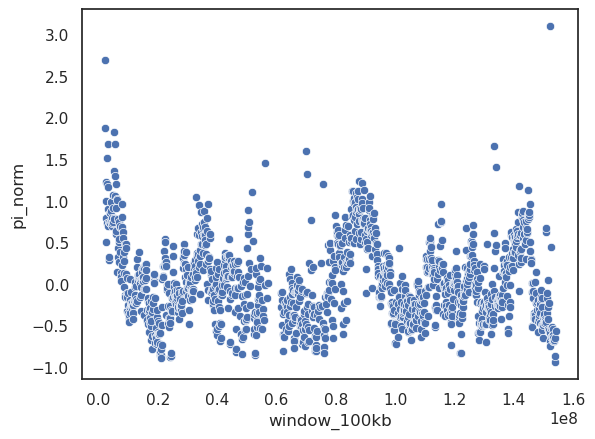

In [27]:
sns.scatterplot(mean_across_species.loc[(mean_across_species.chr_type == "chrX") & (mean_across_species.species_used >= 50)],
               x="window_100kb", y="pi_norm")

[(-1.6307672821253458, 3.0)]

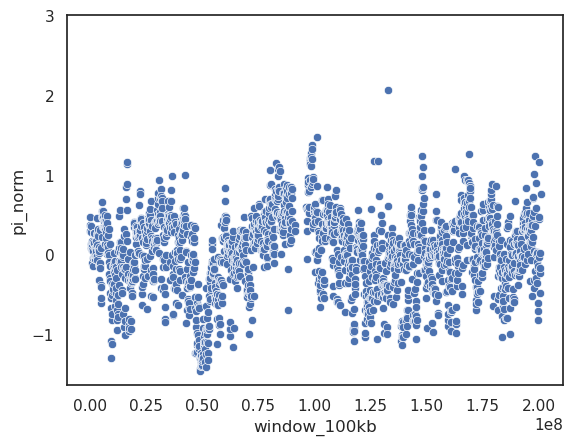

In [28]:
g = sns.scatterplot(mean_across_species.loc[(mean_across_species.chrom == 'NC_060927.1') & (mean_across_species.species_used >= 50)],
               x="window_100kb", y="pi_norm")
g.set(ylim=(None, 3))

[(-1.8527621434893473, 3.0)]

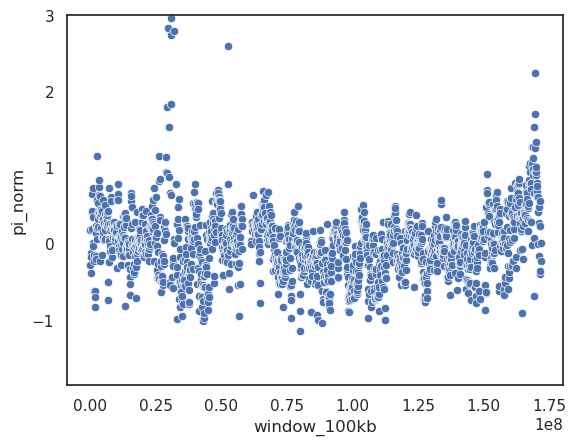

In [29]:
g = sns.scatterplot(mean_across_species.loc[(mean_across_species.chrom == 'NC_060930.1') & (mean_across_species.species_used >= 50)],
               x="window_100kb", y="pi_norm")
g.set(ylim=(None, 3))

In [30]:
mean_across_species

,chr_type,chrom,window_100kb,pi_norm,species_used
0,aut,NC_060925.1,0,0.875651,27
1,aut,NC_060925.1,100000,-1.111088,1
2,aut,NC_060925.1,200000,0.364520,50
3,aut,NC_060925.1,300000,0.132990,93
4,aut,NC_060925.1,400000,-0.113739,128
...,...,...,...,...,...
28612,chrX,NC_060947.1,153800000,-0.651706,110
28613,chrX,NC_060947.1,153900000,-0.938085,92
28614,chrX,NC_060947.1,154000000,-0.868437,57
28615,chrX,NC_060947.1,154100000,-0.563275,130


In [31]:
mean_across_species.loc[(mean_across_species.chr_type == "chrX")]#.species_used.min()

,chr_type,chrom,window_100kb,pi_norm,species_used
27112,chrX,NC_060947.1,100000,2.369964,5
27113,chrX,NC_060947.1,200000,5.918122,1
27114,chrX,NC_060947.1,300000,7.395122,1
27115,chrX,NC_060947.1,400000,1.682395,2
27116,chrX,NC_060947.1,500000,3.398811,4
...,...,...,...,...,...
28612,chrX,NC_060947.1,153800000,-0.651706,110
28613,chrX,NC_060947.1,153900000,-0.938085,92
28614,chrX,NC_060947.1,154000000,-0.868437,57
28615,chrX,NC_060947.1,154100000,-0.563275,130


<Axes: xlabel='species_used', ylabel='Count'>

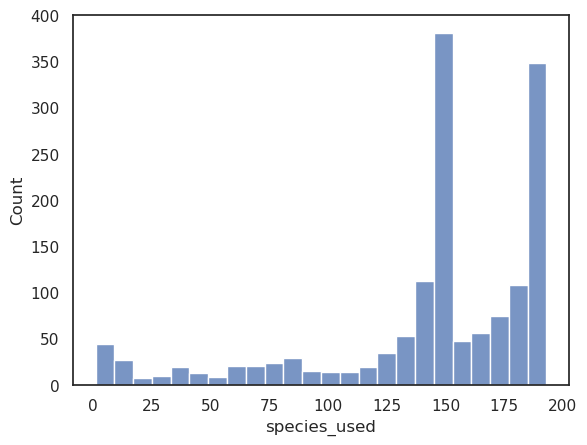

In [32]:
sns.histplot(mean_across_species.loc[(mean_across_species.chr_type == "chrX")], x="species_used")